In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay



Classification Report - Model 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Classification Report - Model 2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



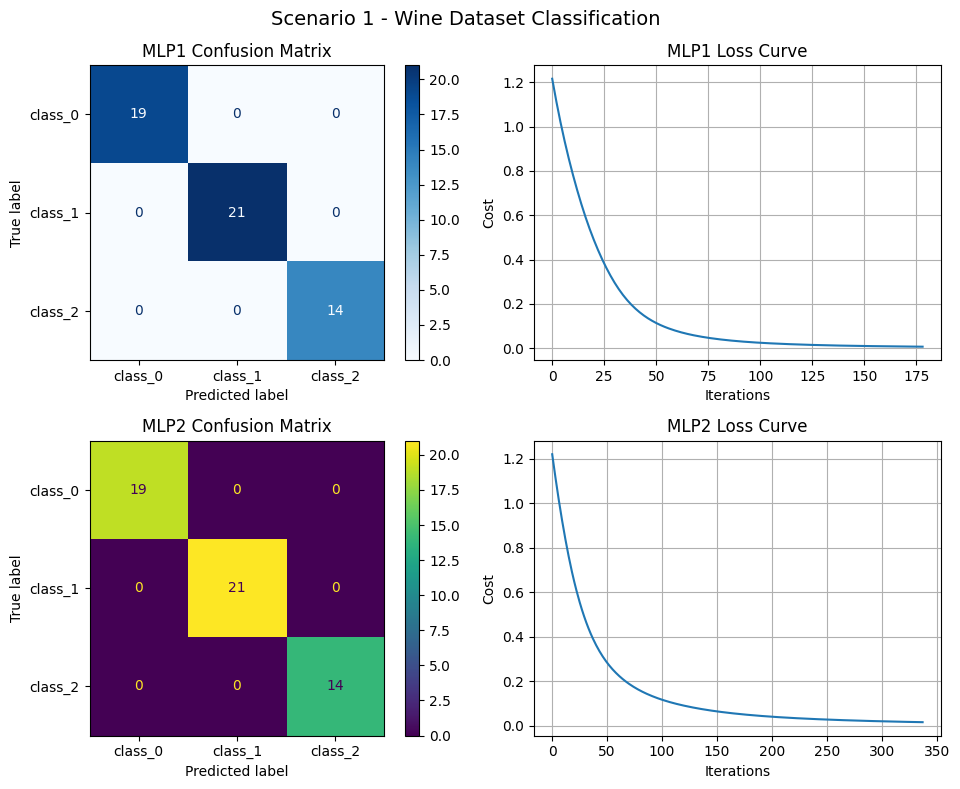

Scenario 1 (MLP1):
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Scenario 1 (MLP2):
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score: 0.9581494431494431
Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score: 0.9757733007733007

Classification Report - Model 1
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


Classification Report - Model 2
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4

    accuracy     

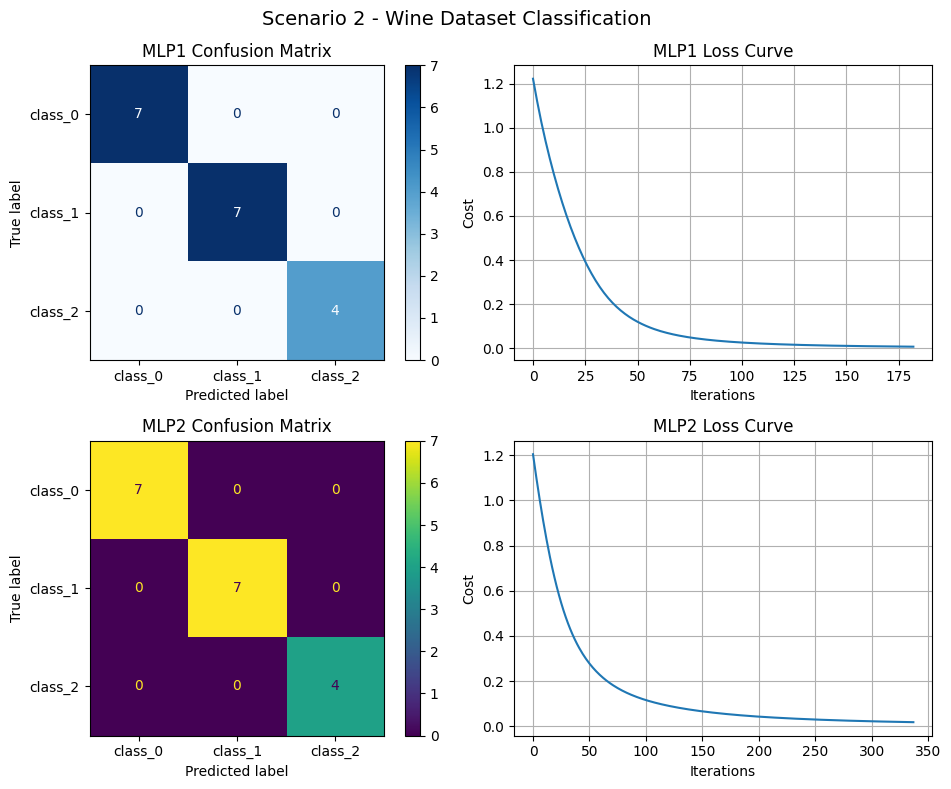

Scenario 2 (MLP1):
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Scenario 2 (MLP2):
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000

Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score: 0.9749368686868687
Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score: 0.9814636752136753
Comparison:
Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy: 0.0
Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy: 0.0
Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score: 0.0
Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score: 0.0


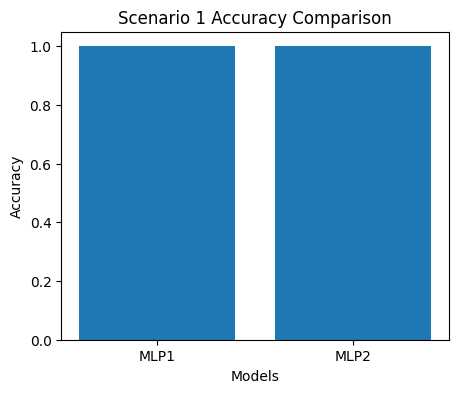

In [2]:
# Load the Wine dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# First scenario: 70% training, 30% test
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second scenario: 90% training, 10% test
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.1, random_state=42
)

# Standardize the features
scaler = StandardScaler()

X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)


# Model 1
mlp1 = MLPClassifier(
    hidden_layer_sizes=(80, 40),
    max_iter=1500,
    learning_rate_init=0.001,
    random_state=42
)


# Model 2
mlp2 = MLPClassifier(
    hidden_layer_sizes=(60,),
    max_iter=1500,
    learning_rate_init=0.001,
    random_state=42
)


def calculate_and_plot_metrics(X_train, y_train, X_test, y_test, title):

    mlp1.fit(X_train, y_train)
    y_pred_mlp1 = mlp1.predict(X_test)

    mlp2.fit(X_train, y_train)
    y_pred_mlp2 = mlp2.predict(X_test)

    print("\nClassification Report - Model 1")
    print(classification_report(y_test, y_pred_mlp1))

    print("\nClassification Report - Model 2")
    print(classification_report(y_test, y_pred_mlp2))


    # Calculate metrics
    def calculate_metrics(y_true, y_pred):
        accuracy = accuracy_score(y_true, y_pred)

        f1 = f1_score(
            y_true,
            y_pred,
            average='weighted'
        )

        precision = precision_score(
            y_true,
            y_pred,
            average='weighted',
            zero_division=1
        )

        recall = recall_score(
            y_true,
            y_pred,
            average='weighted'
        )

        return accuracy, f1, precision, recall


    # Metrics for MLP1
    accuracy_mlp1, f1_mlp1, precision_mlp1, recall_mlp1 = calculate_metrics(
        y_test,
        y_pred_mlp1
    )


    # Metrics for MLP2
    accuracy_mlp2, f1_mlp2, precision_mlp2, recall_mlp2 = calculate_metrics(
        y_test,
        y_pred_mlp2
    )


    # Confusion Matrix and visualization (MLP1)
    cm_mlp1 = confusion_matrix(
        y_test,
        y_pred_mlp1
    )

    disp_mlp1 = ConfusionMatrixDisplay(
        confusion_matrix=cm_mlp1,
        display_labels=wine.target_names
    )

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    disp_mlp1.plot(
        cmap='Blues',
        values_format='d',
        ax=axes[0, 0]
    )

    axes[0, 0].set_title("MLP1 Confusion Matrix")


    # Loss Curve (MLP1)
    axes[0, 1].plot(mlp1.loss_curve_)
    axes[0, 1].set_title("MLP1 Loss Curve")
    axes[0, 1].set_xlabel("Iterations")
    axes[0, 1].set_ylabel("Cost")
    axes[0, 1].grid(True)


    # Confusion Matrix and visualization (MLP2)
    cm_mlp2 = confusion_matrix(
        y_test,
        y_pred_mlp2
    )

    disp_mlp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_mlp2,
        display_labels=wine.target_names
    )

    disp_mlp2.plot(
        cmap='viridis',
        values_format='d',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title("MLP2 Confusion Matrix")


    # Loss Curve (MLP2)
    axes[1, 1].plot(mlp2.loss_curve_)
    axes[1, 1].set_title("MLP2 Loss Curve")
    axes[1, 1].set_xlabel("Iterations")
    axes[1, 1].set_ylabel("Cost")
    axes[1, 1].grid(True)


    # Calculate 10-fold cross-validation results
    cross_val_scores1_mlp1 = cross_val_score(
        mlp1,
        X_train,
        y_train,
        cv=10,
        scoring='f1_weighted'
    )

    cross_val_scores1_mlp2 = cross_val_score(
        mlp2,
        X_train,
        y_train,
        cv=10,
        scoring='f1_weighted'
    )


    plt.suptitle(
        title + " - Wine Dataset Classification",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


    return (
        accuracy_mlp1,
        f1_mlp1,
        precision_mlp1,
        recall_mlp1,
        accuracy_mlp2,
        f1_mlp2,
        precision_mlp2,
        recall_mlp2,
        cross_val_scores1_mlp1,
        cross_val_scores1_mlp2
    )


# ============================================================
# Calculations for Scenario 1
# ============================================================

accuracy1_mlp1, f1_1_mlp1, precision1_mlp1, recall1_mlp1, \
accuracy1_mlp2, f1_1_mlp2, precision1_mlp2, recall1_mlp2, \
cross_val_scores1_mlp1, cross_val_scores1_mlp2 = calculate_and_plot_metrics(
    X_train1,
    y_train1,
    X_test1,
    y_test1,
    "Scenario 1"
)


# Outputs for Scenario 1
print("Scenario 1 (MLP1):")

print(
    f"Accuracy: {accuracy1_mlp1:.4f}\n"
    f"F1 Score: {f1_1_mlp1:.4f}\n"
    f"Precision: {precision1_mlp1:.4f}\n"
    f"Recall: {recall1_mlp1:.4f}\n"
)

print("Scenario 1 (MLP2):")

print(
    f"Accuracy: {accuracy1_mlp2:.4f}\n"
    f"F1 Score: {f1_1_mlp2:.4f}\n"
    f"Precision: {precision1_mlp2:.4f}\n"
    f"Recall: {recall1_mlp2:.4f}\n"
)

print(
    "Scenario 1 10-Fold Cross-Validation (MLP1) F1 Score:",
    np.mean(cross_val_scores1_mlp1)
)

print(
    "Scenario 1 10-Fold Cross-Validation (MLP2) F1 Score:",
    np.mean(cross_val_scores1_mlp2)
)


# ============================================================
# Calculations for Scenario 2
# ============================================================

accuracy2_mlp1, f1_2_mlp1, precision2_mlp1, recall2_mlp1, \
accuracy2_mlp2, f1_2_mlp2, precision2_mlp2, recall2_mlp2, \
cross_val_scores2_mlp1, cross_val_scores2_mlp2 = calculate_and_plot_metrics(
    X_train2,
    y_train2,
    X_test2,
    y_test2,
    "Scenario 2"
)


# Outputs for Scenario 2
print("Scenario 2 (MLP1):")

print(
    f"Accuracy: {accuracy2_mlp1:.4f}\n"
    f"F1 Score: {f1_2_mlp1:.4f}\n"
    f"Precision: {precision2_mlp1:.4f}\n"
    f"Recall: {recall2_mlp1:.4f}\n"
)

print("Scenario 2 (MLP2):")

print(
    f"Accuracy: {accuracy2_mlp2:.4f}\n"
    f"F1 Score: {f1_2_mlp2:.4f}\n"
    f"Precision: {precision2_mlp2:.4f}\n"
    f"Recall: {recall2_mlp2:.4f}\n"
)

print(
    "Scenario 2 10-Fold Cross-Validation (MLP1) F1 Score:",
    np.mean(cross_val_scores2_mlp1)
)

print(
    "Scenario 2 10-Fold Cross-Validation (MLP2) F1 Score:",
    np.mean(cross_val_scores2_mlp2)
)


# ============================================================
# Scenario 1 and Scenario 2 Comparison
# ============================================================

print("Comparison:")

print(
    "Scenario 1 (MLP1) Accuracy - Scenario 2 (MLP1) Accuracy:",
    accuracy1_mlp1 - accuracy2_mlp1
)

print(
    "Scenario 1 (MLP2) Accuracy - Scenario 2 (MLP2) Accuracy:",
    accuracy1_mlp2 - accuracy2_mlp2
)

print(
    "Scenario 1 (MLP1) F1 Score - Scenario 2 (MLP1) F1 Score:",
    f1_1_mlp1 - f1_2_mlp1
)

print(
    "Scenario 1 (MLP2) F1 Score - Scenario 2 (MLP2) F1 Score:",
    f1_1_mlp2 - f1_2_mlp2
)


# ============================================================
# Accuracy Comparison for Scenario 1
# ============================================================

models = ["MLP1", "MLP2"]
accuracy = [accuracy1_mlp1, accuracy1_mlp2]

plt.figure(figsize=(5, 4))

plt.bar(
    models,
    accuracy
)

plt.title("Scenario 1 Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()